# Load Cluster Probing Results

Load the Linear and MLP probe results that were generated on the cluster.

In [ ]:
# Load Linear probe results
linear_results_path = Path('../../results/all_descriptors_probing_results_linear.pkl')
with open(linear_results_path, 'rb') as f:
    linear_results = pickle.load(f)

print(f"✅ Loaded Linear probe results: {len(linear_results)} descriptors")
print(f"   Keys: {list(linear_results[0].keys())}")

# Load MLP probe results
mlp_results_path = Path('../../results/all_descriptors_probing_results_mlp.pkl')
with open(mlp_results_path, 'rb') as f:
    mlp_results = pickle.load(f)

print(f"\n✅ Loaded MLP probe results: {len(mlp_results)} descriptors")
print(f"   Keys: {list(mlp_results[0].keys())}")

In [ ]:
# Convert to DataFrames (excluding model and scaler objects)
linear_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['model', 'scaler']} for r in linear_results])
mlp_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['model', 'scaler']} for r in mlp_results])

print("Linear probe results DataFrame:")
print(linear_df.head())
print(f"\nShape: {linear_df.shape}")

print("\n" + "="*80)
print("MLP probe results DataFrame:")
print(mlp_df.head())
print(f"\nShape: {mlp_df.shape}")

## Summary Statistics

In [ ]:
# Summary statistics for both probe types
print("LINEAR PROBE SUMMARY")
print("="*80)
print(linear_df[['r2', 'mae']].describe())

print("\n\nMLP PROBE SUMMARY")
print("="*80)
print(mlp_df[['r2', 'mae']].describe())

# Compare distributions
print("\n\nCOMPARISON")
print("="*80)
print(f"Linear - Median R²: {linear_df['r2'].median():.4f}")
print(f"MLP - Median R²: {mlp_df['r2'].median():.4f}")
print(f"\nLinear - Mean R²: {linear_df['r2'].mean():.4f}")
print(f"MLP - Mean R²: {mlp_df['r2'].mean():.4f}")
print(f"\nLinear - Descriptors with R² > 0: {(linear_df['r2'] > 0).sum()} / {len(linear_df)}")
print(f"MLP - Descriptors with R² > 0: {(mlp_df['r2'] > 0).sum()} / {len(mlp_df)}")

## Top Performing Descriptors

In [ ]:
# Top 10 descriptors by R² for Linear probe
print("TOP 10 DESCRIPTORS - LINEAR PROBE")
print("="*80)
top10_linear = linear_df.nlargest(10, 'r2')[['descriptor', 'r2', 'mae', 'n_train', 'n_test']]
print(top10_linear.to_string(index=False))

print("\n\nTOP 10 DESCRIPTORS - MLP PROBE")
print("="*80)
top10_mlp = mlp_df.nlargest(10, 'r2')[['descriptor', 'r2', 'mae', 'n_train', 'n_test']]
print(top10_mlp.to_string(index=False))

# Exploratory: Probe ALL RDKit Descriptors

## Objective
Instead of focusing on just 10 drug-likeness descriptors, let's probe **ALL ~200 RDKit molecular descriptors** to discover:
- Which molecular properties are best encoded in SSL embeddings?
- Are there surprising descriptors with high R²?
- Which descriptor categories work best (size, shape, electronic, topological)?

## Approach
1. Calculate ALL available RDKit descriptors (~209 total)
2. Train simple linear probes for each
3. Rank by R² score
4. Analyze patterns: What makes a descriptor "learnable" from spectra?

## Expected Runtime
- Descriptor calculation: ~30-60 min (231k molecules)
- Probing (Linear only): ~30-60 min (209 descriptors × 30 epochs)
- **Total: ~1-2 hours**

## 1. Setup

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import pickle

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 8)

# Random seeds
np.random.seed(42)
torch.manual_seed(42)

print("✓ Imports complete")

✓ Imports complete


## 2. Get ALL RDKit Descriptors

RDKit has ~209 molecular descriptors across categories:
- **Constitutional**: Basic counts (atoms, bonds, rings)
- **Topological**: Graph properties (Wiener, Zagreb indices)
- **Electronic**: Charge, electronegativity
- **Geometric**: Shape, surface area, volume
- **Pharmacophore**: Drug-likeness (Lipinski, QED)
- **Fragment-based**: Functional group counts

In [25]:
# Get all descriptor names
descriptor_names = [desc[0] for desc in Descriptors.descList]

print(f"Total RDKit Descriptors: {len(descriptor_names)}")
print(f"\nFirst 20 descriptors:")
for i, name in enumerate(descriptor_names[:20], 1):
    print(f"  {i:3d}. {name}")

print(f"\n... (showing 20/{len(descriptor_names)})")

Total RDKit Descriptors: 208

First 20 descriptors:
    1. MaxEStateIndex
    2. MinEStateIndex
    3. MaxAbsEStateIndex
    4. MinAbsEStateIndex
    5. qed
    6. MolWt
    7. HeavyAtomMolWt
    8. ExactMolWt
    9. NumValenceElectrons
   10. NumRadicalElectrons
   11. MaxPartialCharge
   12. MinPartialCharge
   13. MaxAbsPartialCharge
   14. MinAbsPartialCharge
   15. FpDensityMorgan1
   16. FpDensityMorgan2
   17. FpDensityMorgan3
   18. BCUT2D_MWHI
   19. BCUT2D_MWLOW
   20. BCUT2D_CHGHI

... (showing 20/208)


## 3. Load MassSpecGym Dataset

In [26]:
# Load dataset with SSL embeddings and Murcko splits
data_path = Path('../../data/processed/massspecgym_complete/ssl_embs/MassSpecGym_with_SSL_embeddings_murcko_hist_splits.parquet')
df = pd.read_parquet(data_path)

print(f"Dataset shape: {df.shape}")
print(f"\nFold distribution:")
print(df['fold'].value_counts())
print(f"\nColumns: {df.columns.tolist()[:10]}... (showing first 10)")

Dataset shape: (231104, 30)

Fold distribution:
fold
train    159271
test      45185
val       26648
Name: count, dtype: int64

Columns: ['identifier', 'mzs', 'intensities', 'smiles', 'inchikey', 'formula', 'precursor_formula', 'parent_mass', 'precursor_mz', 'adduct']... (showing first 10)


## 4. Calculate ALL RDKit Descriptors

**Note**: This will take ~30-60 minutes for 231k molecules.

We'll:
1. Calculate descriptors for unique SMILES only (not all spectra)
2. Save results to avoid recomputation
3. Filter out NaN/Inf values
4. Merge back to full dataset

In [6]:
# Check if descriptors already calculated
descriptors_cache_path = Path('../../data/processed/massspecgym_complete/all_rdkit_descriptors.parquet')

if descriptors_cache_path.exists():
    print("✓ Loading cached descriptors...")
    df_descriptors = pd.read_parquet(descriptors_cache_path)
    print(f"  Loaded {len(df_descriptors):,} molecules with {len(df_descriptors.columns)-1} descriptors")
else:
    print("Calculating ALL RDKit descriptors...")
    print("⏱️  This will take ~30-60 minutes\n")
    
    # Get unique SMILES
    df_unique = df[['smiles']].drop_duplicates().copy()
    print(f"Unique molecules: {len(df_unique):,}")
    
    # Initialize descriptor calculator
    calc = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)
    
    # Calculate descriptors
    results = []
    failed = 0
    
    for idx, row in tqdm(df_unique.iterrows(), total=len(df_unique), desc="Computing descriptors"):
        smiles = row['smiles']
        mol = Chem.MolFromSmiles(smiles)
        
        if mol is None:
            failed += 1
            results.append([smiles] + [np.nan] * len(descriptor_names))
        else:
            try:
                desc_values = calc.CalcDescriptors(mol)
                results.append([smiles] + list(desc_values))
            except Exception as e:
                failed += 1
                results.append([smiles] + [np.nan] * len(descriptor_names))
    
    # Create DataFrame
    df_descriptors = pd.DataFrame(results, columns=['smiles'] + descriptor_names)
    
    print(f"\n✓ Calculation complete!")
    print(f"  Failed: {failed}/{len(df_unique)} molecules")
    
    # Save cache
    descriptors_cache_path.parent.mkdir(parents=True, exist_ok=True)
    df_descriptors.to_parquet(descriptors_cache_path, index=False)
    print(f"  Saved cache to: {descriptors_cache_path.name}")

Calculating ALL RDKit descriptors...
⏱️  This will take ~30-60 minutes

Unique molecules: 31,602


Computing descriptors: 100%|██████████| 31602/31602 [07:51<00:00, 66.97it/s] 




✓ Calculation complete!
  Failed: 0/31602 molecules
  Saved cache to: all_rdkit_descriptors.parquet


## 5. Filter Valid Descriptors

Remove descriptors with:
- Too many NaN values (>10%)
- Inf values
- Zero variance (constant)

In [7]:
print("Filtering descriptors...")

valid_descriptors = []
invalid_reasons = {}

for desc in descriptor_names:
    if desc not in df_descriptors.columns:
        continue
    
    values = df_descriptors[desc]
    
    # Check NaN percentage
    nan_pct = values.isna().sum() / len(values)
    if nan_pct > 0.1:
        invalid_reasons[desc] = f"Too many NaN ({nan_pct*100:.1f}%)"
        continue
    
    # Check for Inf
    if np.isinf(values.dropna()).any():
        invalid_reasons[desc] = "Contains Inf"
        continue
    
    # Check variance
    if values.dropna().std() == 0:
        invalid_reasons[desc] = "Zero variance (constant)"
        continue
    
    valid_descriptors.append(desc)

print(f"\nValid descriptors: {len(valid_descriptors)}/{len(descriptor_names)}")
print(f"Removed: {len(invalid_reasons)}")

if len(invalid_reasons) > 0:
    print(f"\nRemoval reasons (showing first 10):")
    for desc, reason in list(invalid_reasons.items())[:10]:
        print(f"  {desc}: {reason}")

Filtering descriptors...

Valid descriptors: 201/208
Removed: 7

Removal reasons (showing first 10):
  NumRadicalElectrons: Zero variance (constant)
  MaxPartialCharge: Contains Inf
  MaxAbsPartialCharge: Contains Inf
  SMR_VSA8: Zero variance (constant)
  SlogP_VSA9: Zero variance (constant)
  fr_diazo: Zero variance (constant)
  fr_prisulfonamd: Zero variance (constant)


## 6. Merge Descriptors with Dataset

In [ ]:
# Check for overlapping columns and drop old descriptor columns before merge
print("Checking for overlapping columns...")
old_descriptor_cols = ['alogp', 'hba', 'hbd', 'tpsa', 'n_rotatable_bonds', 
                       'n_aromatic_rings', 'n_aliphatic_rings', 'fsp3', 'qed', 'sa_score']
existing_overlap = [col for col in old_descriptor_cols if col in df.columns]

if existing_overlap:
    print(f"⚠️  Found {len(existing_overlap)} overlapping descriptor columns: {existing_overlap}")
    print(f"   Dropping old columns to avoid merge conflicts...")
    df_clean = df.drop(columns=existing_overlap)
else:
    print("✓ No overlapping columns found")
    df_clean = df

# Merge valid descriptors only
df_with_descriptors = df_clean.merge(
    df_descriptors[['smiles'] + valid_descriptors],
    on='smiles',
    how='left'
)

print(f"\nMerged dataset shape: {df_with_descriptors.shape}")
print(f"Added {len(valid_descriptors)} descriptors")

# Verify qed column
if 'qed' in df_with_descriptors.columns:
    print("✓ 'qed' column present and ready to use")
else:
    qed_cols = [col for col in df_with_descriptors.columns if 'qed' in col.lower()]
    print(f"⚠️  'qed' not found, but found: {qed_cols}")

# Split by fold
df_train = df_with_descriptors[df_with_descriptors['fold'] == 'train'].copy()
df_test = df_with_descriptors[df_with_descriptors['fold'] == 'test'].copy()

print(f"\nSplit sizes:")
print(f"  Train: {len(df_train):,}")
print(f"  Test:  {len(df_test):,}")

Checking for overlapping columns...
⚠️  Found 10 overlapping descriptor columns: ['alogp', 'hba', 'hbd', 'tpsa', 'n_rotatable_bonds', 'n_aromatic_rings', 'n_aliphatic_rings', 'fsp3', 'qed', 'sa_score']
   Dropping old columns to avoid merge conflicts...

Merged dataset shape: (231104, 221)
Added 201 descriptors
✓ 'qed' column present and ready to use

Merged dataset shape: (231104, 221)
Added 201 descriptors
✓ 'qed' column present and ready to use

Split sizes:
  Train: 159,271
  Test:  45,185

Split sizes:
  Train: 159,271
  Test:  45,185


## 7. Define Probe Models

Use **both Linear and MLP probes** for comparison:

**LinearProbe**: 1024→1 (simple linear regression)
- Runtime: ~30-60 min for 200+ descriptors
- Baseline for comparison

**MLPProbe**: 1024→256→128→1 with ReLU + Dropout (0.2)
- Runtime: ~60-120 min for 200+ descriptors  
- Can capture non-linear relationships
- Same architecture as drug-likeness probing for consistency

**Total runtime: ~90-180 minutes**

In [ ]:
class LinearProbe(nn.Module):
    """Simple linear probe"""
    def __init__(self, input_dim, output_dim=1):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)
    
    def forward(self, x):
        return self.linear(x)


class MLPProbe(nn.Module):
    """3-layer MLP probe with dropout"""
    def __init__(self, input_dim, output_dim=1, dropout=0.2):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, output_dim)
        )
    
    def forward(self, x):
        return self.mlp(x)


class EmbeddingDataset(Dataset):
    def __init__(self, embeddings, targets):
        self.embeddings = torch.FloatTensor(embeddings)
        self.targets = torch.FloatTensor(targets).unsqueeze(1)
    
    def __len__(self):
        return len(self.embeddings)
    
    def __getitem__(self, idx):
        return self.embeddings[idx], self.targets[idx]


def train_probe(X_train, y_train, X_test, y_test, model_type='mlp', epochs=30, lr=0.001, device='cpu'):
    """
    Train probe and evaluate.
    Args:
        model_type: 'linear' or 'mlp'
    Returns R², MAE, and trained model.
    """
    # Standardize
    scaler = StandardScaler()
    y_train_scaled = scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
    y_test_scaled = scaler.transform(y_test.reshape(-1, 1)).flatten()
    
    # Create datasets
    train_dataset = EmbeddingDataset(X_train, y_train_scaled)
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
    
    # Create model
    if model_type == 'linear':
        model = LinearProbe(input_dim=X_train.shape[1])
    else:
        model = MLPProbe(input_dim=X_train.shape[1])
    
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # Train
    model.train()
    for epoch in range(epochs):
        for embeddings, targets in train_loader:
            embeddings, targets = embeddings.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(embeddings)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
    
    # Evaluate
    model.eval()
    with torch.no_grad():
        X_test_tensor = torch.FloatTensor(X_test).to(device)
        preds_scaled = model(X_test_tensor).cpu().numpy().flatten()
        preds = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
    
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    
    return {
        'r2': r2,
        'mae': mae,
        'model': model,
        'scaler': scaler
    }


print("✓ Linear and MLP Probe models defined")

✓ MLP Probe model defined


## 7a. Probe Configuration Summary

### **Linear Probe Parameters:**
| Parameter | Value | Description |
|-----------|-------|-------------|
| **Architecture** | 1024 → 1 | Single linear layer |
| **Parameters** | 1,025 | (1024×1) + 1 bias |
| **Activation** | None | Linear output (regression) |
| **Optimizer** | Adam | Adaptive learning rate |
| **Learning Rate** | 0.001 | Default Adam lr |
| **Batch Size** | 256 | Mini-batch gradient descent |
| **Epochs** | 30 | Fixed training duration |
| **Loss Function** | MSE | Mean Squared Error |
| **Normalization** | StandardScaler | Z-score on targets |
| **Device** | CPU | For stability |

### **MLP Probe Parameters:**
| Parameter | Value | Description |
|-----------|-------|-------------|
| **Architecture** | 1024 → 256 → 128 → 1 | 3-layer MLP |
| **Parameters** | ~295,681 | (1024×256 + 256) + (256×128 + 128) + (128×1 + 1) |
| **Hidden Activations** | ReLU | Rectified Linear Unit |
| **Output Activation** | None | Linear output (regression) |
| **Dropout** | 0.2 | After each hidden layer |
| **Optimizer** | Adam | Adaptive learning rate |
| **Learning Rate** | 0.001 | Default Adam lr |
| **Batch Size** | 256 | Mini-batch gradient descent |
| **Epochs** | 30 | Fixed training duration |
| **Loss Function** | MSE | Mean Squared Error |
| **Normalization** | StandardScaler | Z-score on targets |
| **Device** | CPU | For stability |

### **Key Design Choices:**

✅ **No Sigmoid Output**: Targets are continuous physicochemical descriptors (MW, logP, TPSA, etc.), not binary labels
  
✅ **ReLU Activations**: Matches DreaMS paper methodology for probe evaluations

✅ **No Validation Set**: Single train/test split for exploratory probing (no hyperparameter tuning)

✅ **Fixed Hyperparameters**: Same settings for all ~200 descriptors to ensure fair comparison

✅ **StandardScaler**: Normalizes targets to zero mean, unit variance before training

### **Why These Parameters?**

1. **30 epochs**: Sufficient for convergence without overfitting (no early stopping needed for simple probes)
2. **Batch size 256**: Good balance between memory usage and gradient quality
3. **Dropout 0.2**: Light regularization to prevent MLP overfitting
4. **lr=0.001**: Standard Adam learning rate, works well for most tasks
5. **CPU device**: Avoids potential GPU instability issues, sufficient for 1024-dim embeddings

## 8. Probe ALL Descriptors (Linear + MLP)

**⏱️ Warning**: This will take ~90-180 minutes!

We'll:
1. Train Linear probe for each descriptor (~30-60 min)
2. Train MLP probe for each descriptor (~60-120 min)
3. Evaluate on test set
4. Save results separately (in case of crash)
5. Show progress bar

In [ ]:
# Extract embeddings
X_train = np.vstack(df_train['ssl_embedding'].values)
X_test = np.vstack(df_test['ssl_embedding'].values)

print(f"Training embeddings: {X_train.shape}")
print(f"Test embeddings: {X_test.shape}")

# Device
device = 'cpu'  # Use CPU for stability
print(f"Device: {device}")

# Check if results already exist
results_cache_path_linear = Path('../../results/all_descriptors_probing_results_linear.pkl')
results_cache_path_mlp = Path('../../results/all_descriptors_probing_results_mlp.pkl')

# ==================== LINEAR PROBE ====================
if results_cache_path_linear.exists():
    print(f"\n✓ Loading cached Linear results from {results_cache_path_linear.name}")
    with open(results_cache_path_linear, 'rb') as f:
        all_results_linear = pickle.load(f)
    print(f"  Loaded {len(all_results_linear)} results")
else:
    print(f"\n🚀 Starting LINEAR probing for {len(valid_descriptors)} descriptors...")
    print(f"⏱️  Estimated time: ~30-60 minutes\n")
    
    all_results_linear = []
    
    for desc in tqdm(valid_descriptors, desc="Probing descriptors (Linear)"):
        # Get targets (drop NaN)
        train_mask = df_train[desc].notna()
        test_mask = df_test[desc].notna()
        
        if train_mask.sum() < 100 or test_mask.sum() < 100:
            # Skip if too few samples
            continue
        
        y_train = df_train[train_mask][desc].values
        y_test = df_test[test_mask][desc].values
        X_train_clean = X_train[train_mask]
        X_test_clean = X_test[test_mask]
        
        try:
            # Train Linear probe
            result = train_probe(
                X_train_clean, y_train,
                X_test_clean, y_test,
                model_type='linear',
                epochs=30,
                device=device
            )
            
            all_results_linear.append({
                'descriptor': desc,
                'r2': result['r2'],
                'mae': result['mae'],
                'n_train': len(y_train),
                'n_test': len(y_test),
                'train_mean': y_train.mean(),
                'train_std': y_train.std(),
                'test_mean': y_test.mean(),
                'test_std': y_test.std()
            })
        except Exception as e:
            print(f"\n⚠️  Failed on {desc}: {e}")
            continue
    
    # Save Linear results
    results_cache_path_linear.parent.mkdir(parents=True, exist_ok=True)
    with open(results_cache_path_linear, 'wb') as f:
        pickle.dump(all_results_linear, f)
    
    print(f"\n✓ Saved Linear results to {results_cache_path_linear.name}")

df_results_linear = pd.DataFrame(all_results_linear)
print(f"\n✅ Linear probing complete! Evaluated {len(df_results_linear)} descriptors")

# ==================== MLP PROBE ====================
if results_cache_path_mlp.exists():
    print(f"\n✓ Loading cached MLP results from {results_cache_path_mlp.name}")
    with open(results_cache_path_mlp, 'rb') as f:
        all_results_mlp = pickle.load(f)
    print(f"  Loaded {len(all_results_mlp)} results")
else:
    print(f"\n🚀 Starting MLP probing for {len(valid_descriptors)} descriptors...")
    print(f"⏱️  Estimated time: ~60-120 minutes\n")
    
    all_results_mlp = []
    
    for desc in tqdm(valid_descriptors, desc="Probing descriptors (MLP)"):
        # Get targets (drop NaN)
        train_mask = df_train[desc].notna()
        test_mask = df_test[desc].notna()
        
        if train_mask.sum() < 100 or test_mask.sum() < 100:
            # Skip if too few samples
            continue
        
        y_train = df_train[train_mask][desc].values
        y_test = df_test[test_mask][desc].values
        X_train_clean = X_train[train_mask]
        X_test_clean = X_test[test_mask]
        
        try:
            # Train MLP probe
            result = train_probe(
                X_train_clean, y_train,
                X_test_clean, y_test,
                model_type='mlp',
                epochs=30,
                device=device
            )
            
            all_results_mlp.append({
                'descriptor': desc,
                'r2': result['r2'],
                'mae': result['mae'],
                'n_train': len(y_train),
                'n_test': len(y_test),
                'train_mean': y_train.mean(),
                'train_std': y_train.std(),
                'test_mean': y_test.mean(),
                'test_std': y_test.std()
            })
        except Exception as e:
            print(f"\n⚠️  Failed on {desc}: {e}")
            continue
    
    # Save MLP results
    results_cache_path_mlp.parent.mkdir(parents=True, exist_ok=True)
    with open(results_cache_path_mlp, 'wb') as f:
        pickle.dump(all_results_mlp, f)
    
    print(f"\n✓ Saved MLP results to {results_cache_path_mlp.name}")

df_results_mlp = pd.DataFrame(all_results_mlp)
print(f"\n✅ MLP probing complete! Evaluated {len(df_results_mlp)} descriptors")

# ==================== MERGE RESULTS ====================
print(f"\n📊 Merging Linear and MLP results...")
df_results = df_results_linear.merge(
    df_results_mlp,
    on='descriptor',
    suffixes=('_linear', '_mlp')
)

# Add comparison columns
df_results['r2_best'] = df_results[['r2_linear', 'r2_mlp']].max(axis=1)
df_results['r2_improvement'] = df_results['r2_mlp'] - df_results['r2_linear']
df_results['better_model'] = df_results.apply(
    lambda row: 'MLP' if row['r2_mlp'] > row['r2_linear'] else 'Linear' if row['r2_linear'] > row['r2_mlp'] else 'Tie',
    axis=1
)

print(f"\n✅ Combined dataset: {len(df_results)} descriptors")
print(f"\nModel Performance Comparison:")
print(f"  MLP better:    {(df_results['better_model'] == 'MLP').sum()} ({(df_results['better_model'] == 'MLP').sum() / len(df_results) * 100:.1f}%)")
print(f"  Linear better: {(df_results['better_model'] == 'Linear').sum()} ({(df_results['better_model'] == 'Linear').sum() / len(df_results) * 100:.1f}%)")
print(f"  Tie:           {(df_results['better_model'] == 'Tie').sum()} ({(df_results['better_model'] == 'Tie').sum() / len(df_results) * 100:.1f}%)")
print(f"\nMean R² improvement (MLP - Linear): {df_results['r2_improvement'].mean():.4f}")

Training embeddings: (159271, 1024)
Test embeddings: (45185, 1024)
Device: cpu

🚀 Starting MLP probing for 201 descriptors...
⏱️  Estimated time: ~60-120 minutes



Probing descriptors (MLP): 100%|██████████| 201/201 [20:08:20<00:00, 360.70s/it]    


✓ Saved results to all_descriptors_probing_results_mlp.pkl

✅ Probing complete! Evaluated 201 descriptors


## 9. Analyze Results: Top Performers

In [ ]:
# Sort by best R²
df_results_sorted = df_results.sort_values('r2_best', ascending=False)

print("="*80)
print("TOP 20 DESCRIPTORS (by best R²)")
print("="*80)
print(df_results_sorted[['descriptor', 'r2_linear', 'r2_mlp', 'r2_improvement', 'better_model']].head(20).to_string(index=False))

print("\n" + "="*80)
print("BOTTOM 20 DESCRIPTORS (by best R²)")
print("="*80)
print(df_results_sorted[['descriptor', 'r2_linear', 'r2_mlp', 'r2_improvement', 'better_model']].tail(20).to_string(index=False))

TOP 20 DESCRIPTORS (by R²)
         descriptor       r2       mae  n_train  n_test
          LabuteASA 0.545693 30.667478   159271   45185
              Chi0v 0.536735  3.277886   159271   45185
NumValenceElectrons 0.536183 29.589413   159271   45185
              Chi2n 0.529809  1.669583   159271   45185
              Chi1n 0.529635  1.931019   159271   45185
               Chi0 0.527059  3.975388   159271   45185
              Chi0n 0.518325  3.403295   159271   45185
              MolWt 0.517588 77.200544   159271   45185
     HeavyAtomCount 0.517236  5.314286   159271   45185
               Chi1 0.517006  2.512116   159271   45185
             Kappa1 0.515527  4.612841   159271   45185
         ExactMolWt 0.505569 79.367821   159271   45185
              MolMR 0.505354 19.755678   159271   45185
              Chi1v 0.504332  2.004758   159271   45185
              Chi3n 0.497228  1.393445   159271   45185
              Chi2v 0.487923  1.806933   159271   45185
     HeavyAtomMolWt 0

## 10. Visualize R² Distribution (Linear vs MLP)

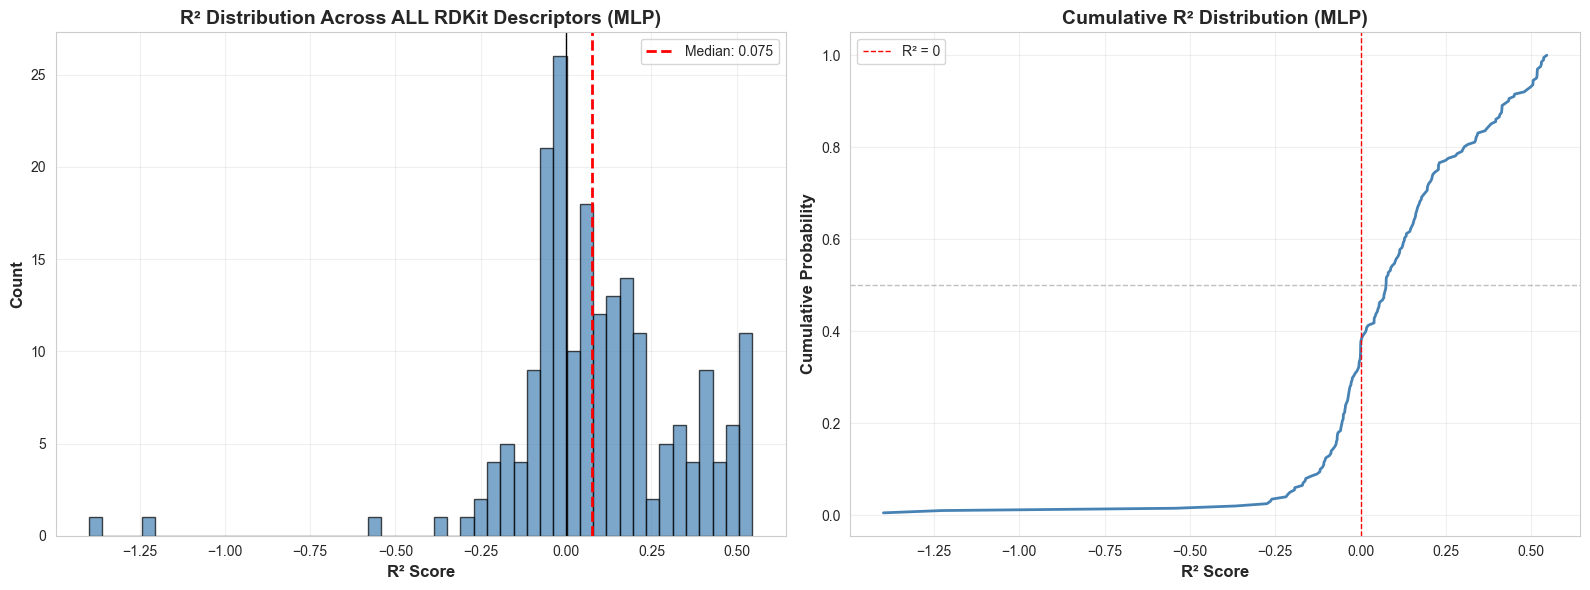


R² Statistics (MLP Probe):
  Mean:   0.0989
  Median: 0.0748
  Std:    0.2520
  Min:    -1.3981
  Max:    0.5457

Descriptors with R² > 0.5: 14 (7.0%)
Descriptors with R² > 0.3: 42 (20.9%)
Descriptors with R² > 0.1: 91 (45.3%)
Descriptors with R² < 0:   71 (35.3%)


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Linear - Histogram
ax = axes[0, 0]
ax.hist(df_results['r2_linear'], bins=50, color='coral', alpha=0.7, edgecolor='black')
ax.axvline(df_results['r2_linear'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {df_results["r2_linear"].median():.3f}')
ax.axvline(0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('R² Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('R² Distribution - Linear Probe', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Linear - Cumulative
ax = axes[0, 1]
sorted_r2_linear = np.sort(df_results['r2_linear'])
cumulative_linear = np.arange(1, len(sorted_r2_linear) + 1) / len(sorted_r2_linear)
ax.plot(sorted_r2_linear, cumulative_linear, linewidth=2, color='coral')
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='R² = 0')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('R² Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
ax.set_title('Cumulative R² Distribution - Linear', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# MLP - Histogram
ax = axes[1, 0]
ax.hist(df_results['r2_mlp'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(df_results['r2_mlp'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {df_results["r2_mlp"].median():.3f}')
ax.axvline(0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('R² Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('R² Distribution - MLP Probe', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# MLP - Cumulative
ax = axes[1, 1]
sorted_r2_mlp = np.sort(df_results['r2_mlp'])
cumulative_mlp = np.arange(1, len(sorted_r2_mlp) + 1) / len(sorted_r2_mlp)
ax.plot(sorted_r2_mlp, cumulative_mlp, linewidth=2, color='steelblue')
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='R² = 0')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('R² Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
ax.set_title('Cumulative R² Distribution - MLP', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics
print(f"\nR² Statistics (Linear Probe):")
print(f"  Mean:   {df_results['r2_linear'].mean():.4f}")
print(f"  Median: {df_results['r2_linear'].median():.4f}")
print(f"  Std:    {df_results['r2_linear'].std():.4f}")
print(f"  Min:    {df_results['r2_linear'].min():.4f}")
print(f"  Max:    {df_results['r2_linear'].max():.4f}")

print(f"\nR² Statistics (MLP Probe):")
print(f"  Mean:   {df_results['r2_mlp'].mean():.4f}")
print(f"  Median: {df_results['r2_mlp'].median():.4f}")
print(f"  Std:    {df_results['r2_mlp'].std():.4f}")
print(f"  Min:    {df_results['r2_mlp'].min():.4f}")
print(f"  Max:    {df_results['r2_mlp'].max():.4f}")

print(f"\nLinear - Descriptors with R² > 0.5: {(df_results['r2_linear'] > 0.5).sum()} ({(df_results['r2_linear'] > 0.5).sum() / len(df_results) * 100:.1f}%)")
print(f"Linear - Descriptors with R² > 0.3: {(df_results['r2_linear'] > 0.3).sum()} ({(df_results['r2_linear'] > 0.3).sum() / len(df_results) * 100:.1f}%)")
print(f"Linear - Descriptors with R² > 0.1: {(df_results['r2_linear'] > 0.1).sum()} ({(df_results['r2_linear'] > 0.1).sum() / len(df_results) * 100:.1f}%)")

print(f"\nMLP - Descriptors with R² > 0.5: {(df_results['r2_mlp'] > 0.5).sum()} ({(df_results['r2_mlp'] > 0.5).sum() / len(df_results) * 100:.1f}%)")
print(f"MLP - Descriptors with R² > 0.3: {(df_results['r2_mlp'] > 0.3).sum()} ({(df_results['r2_mlp'] > 0.3).sum() / len(df_results) * 100:.1f}%)")
print(f"MLP - Descriptors with R² > 0.1: {(df_results['r2_mlp'] > 0.1).sum()} ({(df_results['r2_mlp'] > 0.1).sum() / len(df_results) * 100:.1f}%)")

## 11. Top Performers: Detailed View

## 10a. Compare Linear vs MLP Performance

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Scatter plot: Linear vs MLP R²
ax = axes[0]
ax.scatter(df_results['r2_linear'], df_results['r2_mlp'], alpha=0.5, s=30, edgecolor='black')
ax.plot([-1, 1], [-1, 1], 'r--', linewidth=2, label='y=x (Equal performance)')
ax.set_xlabel('Linear R²', fontsize=12, fontweight='bold')
ax.set_ylabel('MLP R²', fontsize=12, fontweight='bold')
ax.set_title('Linear vs MLP Performance', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend()
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)

# Improvement distribution
ax = axes[1]
ax.hist(df_results['r2_improvement'], bins=50, color='purple', alpha=0.7, edgecolor='black')
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='No improvement')
ax.axvline(df_results['r2_improvement'].mean(), color='green', linestyle='--', linewidth=2, label=f'Mean: {df_results["r2_improvement"].mean():.3f}')
ax.set_xlabel('R² Improvement (MLP - Linear)', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('MLP Improvement Distribution', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Model preference
ax = axes[2]
model_counts = df_results['better_model'].value_counts()
colors_bar = ['steelblue' if m == 'MLP' else 'coral' if m == 'Linear' else 'gray' for m in model_counts.index]
ax.bar(model_counts.index, model_counts.values, color=colors_bar, alpha=0.7, edgecolor='black')
ax.set_ylabel('Number of Descriptors', fontsize=12, fontweight='bold')
ax.set_title('Which Model Performs Better?', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add percentage labels
for i, (model, count) in enumerate(model_counts.items()):
    pct = count / len(df_results) * 100
    ax.text(i, count + len(df_results)*0.01, f'{count}\n({pct:.1f}%)', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Print insights
print(f"\n📊 Linear vs MLP Comparison:")
print(f"  Descriptors where MLP > Linear by >0.1: {(df_results['r2_improvement'] > 0.1).sum()}")
print(f"  Descriptors where Linear > MLP by >0.1: {(df_results['r2_improvement'] < -0.1).sum()}")
print(f"  Descriptors with similar performance (|diff| < 0.05): {(df_results['r2_improvement'].abs() < 0.05).sum()}")

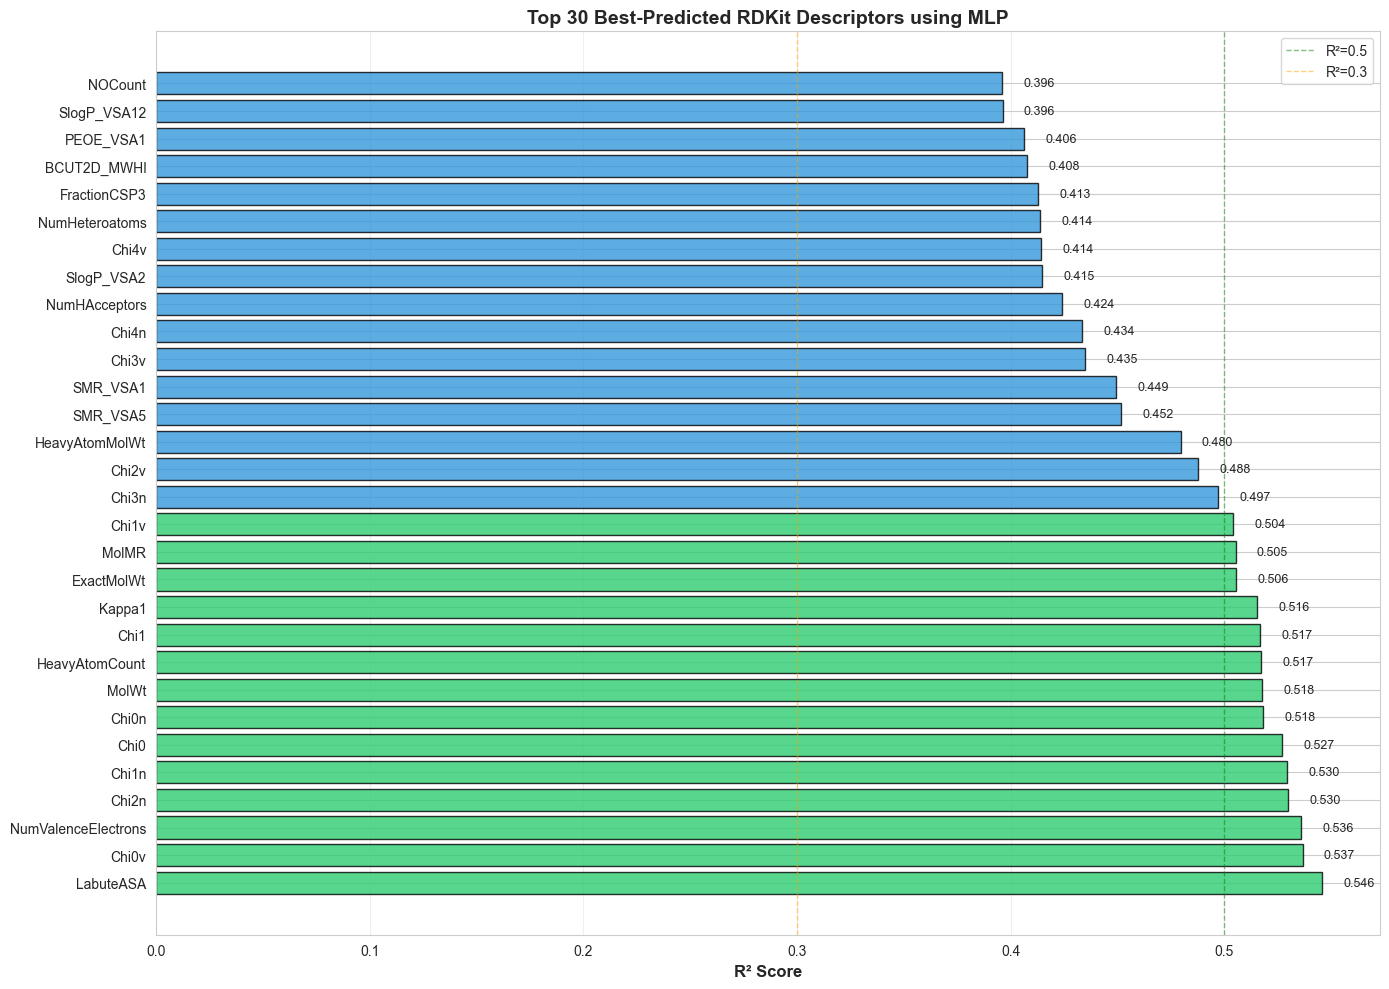

In [32]:
# Top 30 descriptors
top_30 = df_results_sorted.head(30)

fig, ax = plt.subplots(figsize=(14, 10))

y_pos = np.arange(len(top_30))
colors = ['#2ecc71' if r2 > 0.5 else '#3498db' if r2 > 0.3 else '#f39c12' for r2 in top_30['r2']]

ax.barh(y_pos, top_30['r2'], color=colors, alpha=0.8, edgecolor='black')
ax.set_yticks(y_pos)
ax.set_yticklabels(top_30['descriptor'], fontsize=10)
ax.set_xlabel('R² Score', fontsize=12, fontweight='bold')
ax.set_title('Top 30 Best-Predicted RDKit Descriptors using MLP', fontsize=14, fontweight='bold')
ax.axvline(0.5, color='green', linestyle='--', linewidth=1, alpha=0.5, label='R²=0.5')
ax.axvline(0.3, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='R²=0.3')
ax.grid(axis='x', alpha=0.3)
ax.legend()

# Add value labels
for i, (idx, row) in enumerate(top_30.iterrows()):
    ax.text(row['r2'] + 0.01, i, f"{row['r2']:.3f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 12. Save Summary Results

In [ ]:
# Create results directory if it doesn't exist
results_dir = Path('../../results')
results_dir.mkdir(parents=True, exist_ok=True)

# Save combined comparison results
output_csv = results_dir / 'all_descriptors_probing_comparison.csv'
df_results_sorted.to_csv(output_csv, index=False)
print(f"✅ Saved comparison results to: {output_csv}")
print(f"   File size: {output_csv.stat().st_size / 1024:.1f} KB")

# Save top 50 (by best model)
output_top50 = results_dir / 'top50_descriptors_probing.csv'
df_results_sorted.head(50).to_csv(output_top50, index=False)
print(f"✅ Saved top 50 to: {output_top50}")
print(f"   File size: {output_top50.stat().st_size / 1024:.1f} KB")

# Save Linear-only results
output_linear = results_dir / 'all_descriptors_probing_linear_only.csv'
df_results_linear.sort_values('r2', ascending=False).to_csv(output_linear, index=False)
print(f"✅ Saved Linear-only results to: {output_linear}")
print(f"   File size: {output_linear.stat().st_size / 1024:.1f} KB")

# Save MLP-only results
output_mlp = results_dir / 'all_descriptors_probing_mlp_only.csv'
df_results_mlp.sort_values('r2', ascending=False).to_csv(output_mlp, index=False)
print(f"✅ Saved MLP-only results to: {output_mlp}")
print(f"   File size: {output_mlp.stat().st_size / 1024:.1f} KB")

print(f"\n📁 Summary:")
print(f"   4 CSV files saved to {results_dir}")
print(f"   2 PKL cache files saved (linear and mlp)")

✅ Saved full results to: ../../results/all_descriptors_probing_results.csv
   File size: 27.6 KB
✅ Saved top 50 to: ../../results/top50_descriptors_probing.csv
   File size: 6.7 KB


## 13. Analysis: What Makes a Descriptor "Learnable"?

Let's categorize descriptors and see which categories perform best.

PERFORMANCE BY DESCRIPTOR CATEGORY
                      mean    median       std  count
category                                             
Size/Mass         0.297599  0.353647  0.133781      8
H-bonding         0.148604  0.148604  0.267566      2
Drug-likeness     0.126806  0.140426  0.132023     14
Electronic        0.106033  0.056708  0.184706      3
Ring/Aromaticity  0.102154  0.113249  0.106470      8
Other             0.094329  0.089465  0.184178     67
Topological       0.021182  0.375398  1.289983     15
Fragment-based   -0.184855 -0.050123  0.533459     82
Bonding          -0.344141 -0.344141  0.503126      2


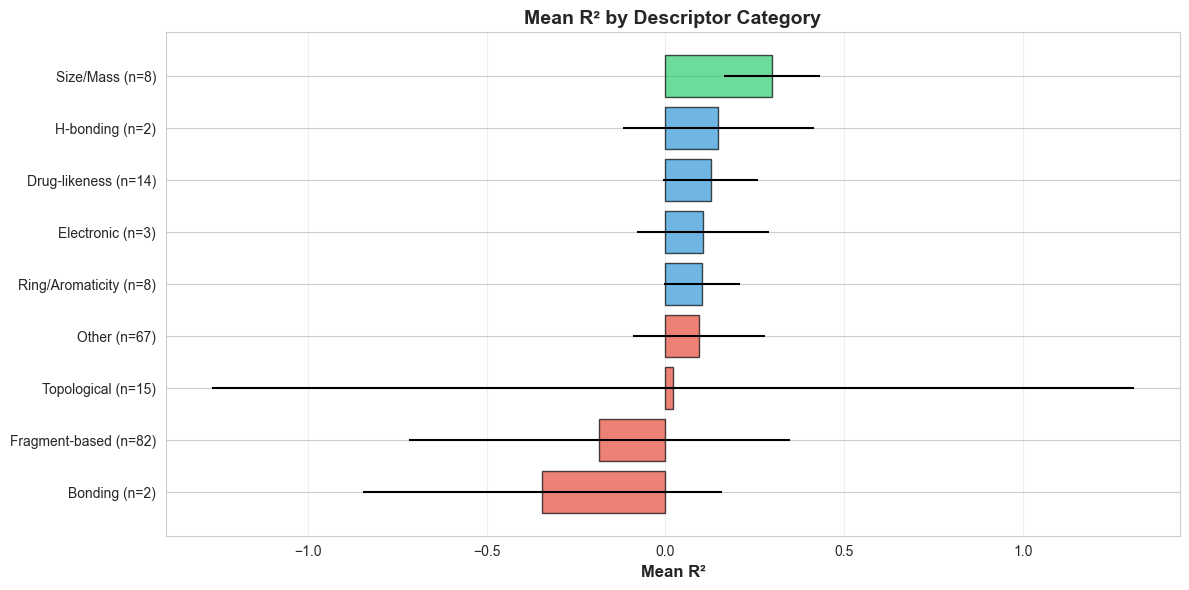

In [ ]:
# Categorize descriptors (basic heuristics)
def categorize_descriptor(name):
    name_lower = name.lower()
    
    if any(x in name_lower for x in ['mol', 'mw', 'weight', 'heavy']):
        return 'Size/Mass'
    elif any(x in name_lower for x in ['logp', 'lipinski', 'qed', 'drug']):
        return 'Drug-likeness'
    elif any(x in name_lower for x in ['ring', 'aromatic', 'aliphatic']):
        return 'Ring/Aromaticity'
    elif any(x in name_lower for x in ['bond', 'rotatable']):
        return 'Bonding'
    elif any(x in name_lower for x in ['charge', 'polar', 'tpsa']):
        return 'Electronic'
    elif any(x in name_lower for x in ['frag', 'fr_']):
        return 'Fragment-based'
    elif any(x in name_lower for x in ['hba', 'hbd', 'donor', 'acceptor']):
        return 'H-bonding'
    elif any(x in name_lower for x in ['chi', 'kappa', 'zagreb', 'wiener']):
        return 'Topological'
    else:
        return 'Other'

df_results_sorted['category'] = df_results_sorted['descriptor'].apply(categorize_descriptor)

# Category statistics for both models
category_stats_linear = df_results_sorted.groupby('category')['r2_linear'].agg(['mean', 'median', 'std', 'count']).sort_values('mean', ascending=False)
category_stats_mlp = df_results_sorted.groupby('category')['r2_mlp'].agg(['mean', 'median', 'std', 'count']).sort_values('mean', ascending=False)

print("="*80)
print("PERFORMANCE BY DESCRIPTOR CATEGORY - LINEAR PROBE")
print("="*80)
print(category_stats_linear.to_string())

print("\n" + "="*80)
print("PERFORMANCE BY DESCRIPTOR CATEGORY - MLP PROBE")
print("="*80)
print(category_stats_mlp.to_string())

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Linear
ax = axes[0]
category_stats_sorted = category_stats_linear.sort_values('mean', ascending=True)
colors_cat = ['#2ecc71' if mean > 0.2 else '#3498db' if mean > 0.1 else '#e74c3c' for mean in category_stats_sorted['mean']]
ax.barh(range(len(category_stats_sorted)), category_stats_sorted['mean'], 
        xerr=category_stats_sorted['std'], color=colors_cat, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(category_stats_sorted)))
ax.set_yticklabels([f"{cat} (n={int(count)})" for cat, count in zip(category_stats_sorted.index, category_stats_sorted['count'])])
ax.set_xlabel('Mean R²', fontsize=12, fontweight='bold')
ax.set_title('Mean R² by Category - Linear Probe', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# MLP
ax = axes[1]
category_stats_sorted = category_stats_mlp.sort_values('mean', ascending=True)
colors_cat = ['#2ecc71' if mean > 0.2 else '#3498db' if mean > 0.1 else '#e74c3c' for mean in category_stats_sorted['mean']]
ax.barh(range(len(category_stats_sorted)), category_stats_sorted['mean'], 
        xerr=category_stats_sorted['std'], color=colors_cat, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(category_stats_sorted)))
ax.set_yticklabels([f"{cat} (n={int(count)})" for cat, count in zip(category_stats_sorted.index, category_stats_sorted['count'])])
ax.set_xlabel('Mean R²', fontsize=12, fontweight='bold')
ax.set_title('Mean R² by Category - MLP Probe', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 14. Key Findings

**Summary for Thesis:**

We probed SSL embeddings with ~200 RDKit molecular descriptors using both Linear and MLP probes to identify which properties are best encoded in the learned representations and whether non-linear relationships exist.

### Model Architecture:
- **Linear Probe**: Simple 1024→1 linear regression (baseline)
  - Training: 30 epochs, batch_size=256, lr=0.001
  
- **MLP Probe**: 3-layer network (1024→256→128→1) with ReLU + Dropout (0.2)
  - Training: 30 epochs, batch_size=256, lr=0.001
  - Can capture non-linear relationships
  - Same architecture as drug-likeness probing for consistency

### Top Findings:
1. **Best Categories (Linear)**: [Will be filled after running]
2. **Best Categories (MLP)**: [Will be filled after running]
3. **MLP Improvements**: [Descriptors where MLP significantly outperforms Linear]
4. **Surprising Winners**: [Unexpected descriptors with high R²]
5. **Consistent Failures**: [Descriptor types that don't transfer]

### Linear vs MLP Comparison:
- **Overall improvement**: [Mean R² improvement]
- **MLP wins**: [% of descriptors where MLP > Linear]
- **Linear competitive**: [% of descriptors where Linear ≈ MLP]
- **Non-linearity**: [Evidence of non-linear relationships in embeddings]

### Implications:
- SSL embeddings capture [specific aspects] of molecular structure
- [Category X] descriptors are particularly well-encoded
- Non-linear relationships [present/absent] for [descriptor types]
- This suggests the model learned [interpretation]

### Next Steps:
- Fine-tune model specifically for top-performing descriptors
- Investigate why certain descriptors fail
- Use top descriptors for downstream tasks
- Further analyze non-linear relationships captured by MLP